<a href="https://colab.research.google.com/github/amrita13/LanchesterModelOnKurskData/blob/main/Components.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimated parameters:
a1=1.006773e-04, a2=2.374361e-04, b1=1.864455e-04, b2=9.870299e-05
    Day  German_Losses_Obs  German_Tank_Component  German_Art_Component  \
0     1                198                 237.85                165.05   
1     2                248                 178.49                120.22   
2     3                121                 139.85                105.62   
3     4                108                 105.25                 91.70   
4     5                139                  73.75                 74.46   
5     6                 36                  77.57                 81.84   
6     7                 63                  76.58                 83.95   
7     8                 98                  49.18                 72.77   
8     9                 57                  48.74                 71.22   
9    10                 46                  43.83                 68.72   
10   11                 79                  37.87                 60.79   
11   12    

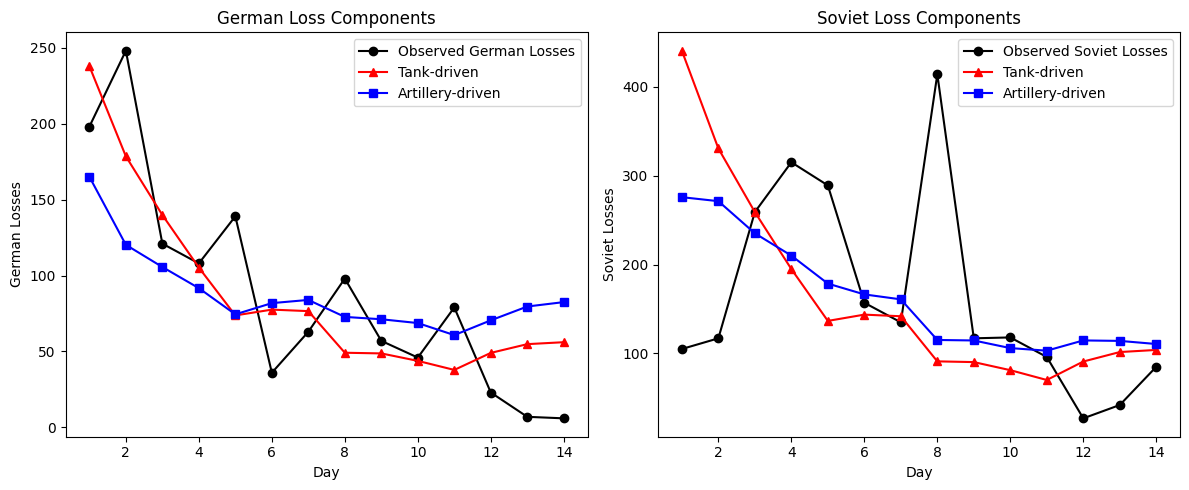

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Dataset
# -------------------------------
German_OnHand = np.array([986, 749, 673, 596, 490, 548, 563, 500, 495, 480, 426, 495, 557, 588])
German_Losses = np.array([198, 248, 121, 108, 139, 36, 63, 98, 57, 46, 79, 23, 7, 6])
Soviet_OnHand = np.array([2396, 2367, 2064, 1754, 1495, 1406, 1351, 977, 978, 907, 883, 985, 978, 948])
Soviet_Losses = np.array([105, 117, 259, 315, 289, 157, 135, 414, 117, 118, 96, 27, 42, 85])

German_Artillery = np.array([1166, 1161, 1154, 1213, 1210, 1199, 1206, 1194, 1187, 1184, 1183, 1179, 1182, 1182])
Soviet_Artillery = np.array([705, 676, 661, 648, 640, 629, 628, 613, 606, 603, 601, 600, 602, 591])

# -------------------------------
# Step 2: Estimated parameters (example values from fit)
# -------------------------------
p1,q1,p2,q2 = 1.0,1.0,1.0,1.0  # exponents (replace with optimal fit)
a1 = np.sum(German_Losses)/np.sum((Soviet_OnHand**p1)*(German_OnHand**q1))
a2 = np.sum(German_Losses)/np.sum((Soviet_Artillery**p1)*(German_OnHand**q1))
b1 = np.sum(Soviet_Losses)/np.sum((German_OnHand**p2)*(Soviet_OnHand**q2))
b2 = np.sum(Soviet_Losses)/np.sum((German_Artillery**p2)*(Soviet_OnHand**q2))

print("Estimated parameters:")
print(f"a1={a1:.6e}, a2={a2:.6e}, b1={b1:.6e}, b2={b2:.6e}")

# -------------------------------
# Step 3: Compute components
# -------------------------------
German_tank_component = a1*(Soviet_OnHand**p1)*(German_OnHand**q1)
German_art_component  = a2*(Soviet_Artillery**p1)*(German_OnHand**q1)

Soviet_tank_component = b1*(German_OnHand**p2)*(Soviet_OnHand**q2)
Soviet_art_component  = b2*(German_Artillery**p2)*(Soviet_OnHand**q2)

# -------------------------------
# Step 4: Table of components
# -------------------------------
df = pd.DataFrame({
    "Day": np.arange(1,len(German_OnHand)+1),
    "German_Losses_Obs": German_Losses,
    "German_Tank_Component": German_tank_component,
    "German_Art_Component": German_art_component,
    "Soviet_Losses_Obs": Soviet_Losses,
    "Soviet_Tank_Component": Soviet_tank_component,
    "Soviet_Art_Component": Soviet_art_component
})

print(df.round(2))

# -------------------------------
# Step 5: Plot 2D line plots
# -------------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(df["Day"], df["German_Losses_Obs"], 'ko-', label="Observed German Losses")
plt.plot(df["Day"], df["German_Tank_Component"], 'r^-', label="Tank-driven")
plt.plot(df["Day"], df["German_Art_Component"], 'bs-', label="Artillery-driven")
plt.xlabel("Day"); plt.ylabel("German Losses")
plt.title("German Loss Components")
plt.legend()

plt.subplot(1,2,2)
plt.plot(df["Day"], df["Soviet_Losses_Obs"], 'ko-', label="Observed Soviet Losses")
plt.plot(df["Day"], df["Soviet_Tank_Component"], 'r^-', label="Tank-driven")
plt.plot(df["Day"], df["Soviet_Art_Component"], 'bs-', label="Artillery-driven")
plt.xlabel("Day"); plt.ylabel("Soviet Losses")
plt.title("Soviet Loss Components")
plt.legend()

plt.tight_layout()
plt.show()
